# Lab 1.1: Tokenization

**Course:** Advanced Natural Language Processing (NLP702/806)

**Instructor:** Dr. Fajri Koto

---

This lab is adapted from Andrej Karpathy's excellent [tokenization tutorial](https://www.youtube.com/watch?v=zduSFxRajkE). We highly recommend watching it for deeper insights!

Tokenization is at the heart of much weirdness of LLMs. Do not brush it off.

- Why can't LLM spell words? **Tokenization**.
- Why can't LLM do super simple string processing tasks like reversing a string? **Tokenization**.
- Why is LLM worse at non-English languages (e.g. Japanese)? **Tokenization**.
- Why is LLM bad at simple arithmetic? **Tokenization**.
- Why did GPT-2 have more than necessary trouble coding in Python? **Tokenization**.
- Why did my LLM abruptly halt when it sees the string "<|endoftext|>"? **Tokenization**.
- What is this weird warning I get about a "trailing whitespace"? **Tokenization**.
- Why the LLM break if I ask it about "SolidGoldMagikarp"? **Tokenization**.
- Why should I prefer to use YAML over JSON with LLMs? **Tokenization**.
- Why is LLM not actually end-to-end language modeling? **Tokenization**.
- What is the real root of suffering? **Tokenization**.

# Section 1: Exploring Tokenization Interactively



Before we dive into the implementation, let's get a hands-on feel for how tokenization works! 

**🎯 Your Turn:** Visit [tiktokenizer.vercel.app](https://tiktokenizer.vercel.app/) and paste the following example string:

```
Tokenization is at the heart of much weirdness of LLMs. Do not brush it off.

127 + 677 = 804
1275 + 6773 = 8041

Egg.
I have an Egg.
egg.
EGG.

تشرفت بلقائك. أنا ChatGPT، نموذج لغوي واسع النطاق طورته شركة OpenAI. لا تتردد في طرح أي أسئلة لديك.

for i in range(1, 101):
    if i % 3 == 0 and i % 5 == 0:
        print("FizzBuzz")
    elif i % 3 == 0:
        print("Fizz")
    elif i % 5 == 0:
        print("Buzz")
    else:
        print(i)
```

**Compare the tokenizers:**
- Switch between **GPT-2** and **GPT-4** tokenizers using the dropdown menu
- Notice how GPT-4's tokenizer is more efficient (fewer tokens for the same text)
- Pay special attention to:
  - How arithmetic expressions are tokenized
  - The difference in tokenizing "Egg" vs "egg" vs "EGG"
  - How Arabic text gets broken down compared to English
  - The tokenization of Python code (especially indentation and keywords)

**Questions to explore:**
- How many tokens does the example produce in GPT-2 vs GPT-4?
- Why does Arabic text use many more tokens than English?
- What patterns do you notice in how numbers are split?

Take a few minutes to experiment and observe the differences!

# Section 2: Understanding Unicode

Before we can understand tokenization, we need to understand how computers represent text. **Unicode** is the universal character encoding standard that allows computers to consistently represent and manipulate text from virtually all writing systems.

**Key Concepts:**
- **Unicode** assigns a unique code point (a number) to every character across all languages
- **UTF-8** is one of the most common encodings that converts Unicode code points into bytes
- Different characters can take different numbers of bytes (1-4 bytes in UTF-8)
- Emojis, special symbols, and non-Latin scripts often require multiple bytes

**📚 Resource:** For an excellent introduction to Unicode, read Nathan Reed's [A Programmer's Introduction to Unicode](https://www.reedbeta.com/blog/programmers-intro-to-unicode/)

Let's explore how different characters are encoded:

## Exploring Character Encodings

Let's take a string with diverse characters:

In [1]:
example_text = "Hello مرحبًا 你好 नमस्ते Здравствуйте こんにちは שלום 안녕하세요 👋"

The following cells demonstrate how Python represents text at different levels:

**Unicode Code Points**: The `ord()` function returns the Unicode code point (integer) for each character

In [2]:
print([ord(x)for x in example_text])

[72, 101, 108, 108, 111, 32, 1605, 1585, 1581, 1576, 1611, 1575, 32, 20320, 22909, 32, 2344, 2350, 2360, 2381, 2340, 2375, 32, 1047, 1076, 1088, 1072, 1074, 1089, 1090, 1074, 1091, 1081, 1090, 1077, 32, 12371, 12435, 12395, 12385, 12399, 32, 1513, 1500, 1493, 1501, 32, 50504, 45397, 54616, 49464, 50836, 32, 128075]


**UTF-8 Bytes**: The `.encode("utf-8")` method converts text into raw bytes (integers from 0-255)

In [3]:
print(list(example_text.encode("utf-8")))

[72, 101, 108, 108, 111, 32, 217, 133, 216, 177, 216, 173, 216, 168, 217, 139, 216, 167, 32, 228, 189, 160, 229, 165, 189, 32, 224, 164, 168, 224, 164, 174, 224, 164, 184, 224, 165, 141, 224, 164, 164, 224, 165, 135, 32, 208, 151, 208, 180, 209, 128, 208, 176, 208, 178, 209, 129, 209, 130, 208, 178, 209, 131, 208, 185, 209, 130, 208, 181, 32, 227, 129, 147, 227, 130, 147, 227, 129, 171, 227, 129, 161, 227, 129, 175, 32, 215, 169, 215, 156, 215, 149, 215, 157, 32, 236, 149, 136, 235, 133, 149, 237, 149, 152, 236, 132, 184, 236, 154, 148, 32, 240, 159, 145, 139]


Notice how:
- ASCII characters (like English letters) use 1 byte each
- Arabic and Korean characters require multiple bytes (typically 2-3 bytes per character)
- Emojis can use 4 bytes or more!
- The string length (character count) is often much smaller than the byte length

## A Complex Unicode Example

The following example uses text from Nathan Reed's blog that showcases some of Unicode's more exotic features:
- **Full-width characters** (Ｕｎｉｃｏｄｅ) - commonly used in Asian typography
- **Circled letters** (🅤🅝🅘🅒🅞🅓🅔) - decorative Unicode variants
- **Flag emojis** (🇺🇳🇮🇨🇴🇩🇪) - composed of special combining characters
- **Regular emojis** (😄) - multi-byte characters
- **Smart quotes** and other typographic symbols

This example demonstrates the dramatic difference between:
- **Character length**: How many characters Python sees (using `len()`)
- **Byte length**: How many bytes are needed to store the text in UTF-8

Run the cell below and notice how the byte count is significantly larger than the character count!

In [4]:
# text from https://www.reedbeta.com/blog/programmers-intro-to-unicode/
text = "Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺‌🇳‌🇮‌🇨‌🇴‌🇩‌🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception."
tokens = text.encode("utf-8") # raw bytes
tokens = list(map(int, tokens)) # convert to a list of integers in range 0..255 for convenience
print('---')
print(text)
print("Length:", len(text))
print('---')
print(tokens)
print("Length:", len(tokens))

---
Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺‌🇳‌🇮‌🇨‌🇴‌🇩‌🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception.
Length: 533
---
[239, 188, 181, 239, 189, 142, 239, 189, 137, 239, 189, 131, 239, 189, 143, 239, 189, 132, 239, 189, 133, 33, 32, 240, 159, 133, 164, 240, 159, 133, 157, 240, 159, 133, 152, 240, 159, 133, 146, 240, 159, 133, 158, 240, 159, 133, 147, 240, 159, 133, 148, 226, 128, 189, 32, 240, 159, 135, 186, 226, 128, 140, 240, 159, 135, 179, 226, 128, 140, 240, 159, 135, 174, 226, 128, 140, 240, 159, 135, 168, 226, 128, 140, 240, 159, 135, 180, 226, 128, 140

# Section 3: Building a Byte Pair Encoding (BPE) Tokenizer

Now that we understand how text is encoded as bytes, let's build a tokenizer! We'll implement a very basic **Byte Pair Encoding (BPE)**, the algorithm used by GPT-2, GPT-3, and many other modern LLMs.

## The BPE Algorithm

BPE is a data compression technique that works by:
1. Starting with individual bytes (0-255) as the initial vocabulary
2. Finding the most frequent pair of consecutive tokens
3. Merging that pair into a new token
4. Repeating until we reach our desired vocabulary size

## Finding Consecutive Byte Pairs

The `get_stats()` function is the core of BPE. It:
- Takes a list of token IDs (in our case, bytes from the UTF-8 encoding)
- Uses `zip(ids, ids[1:])` to create consecutive pairs: `[a,b,c,d]` → `[(a,b), (b,c), (c,d)]`
- Counts how many times each pair appears
- Returns a dictionary where keys are pairs and values are their frequencies

The most frequent pair is the best candidate for merging - it will give us the most compression!

Let's run it on our Unicode example:

In [5]:
def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]): # Pythonic way to iterate consecutive elements
        counts[pair] = counts.get(pair, 0) + 1
    return counts

stats = get_stats(tokens)
print("Pair counts:",
      sorted(((v,k) for k,v in stats.items()), reverse=True))

top_pair = max(stats, key=stats.get)
print("Top pair:", 
      top_pair,
      "with count:",
      stats[top_pair])

Pair counts: [(20, (101, 32)), (15, (240, 159)), (12, (226, 128)), (12, (105, 110)), (10, (115, 32)), (10, (97, 110)), (10, (32, 97)), (9, (32, 116)), (8, (116, 104)), (7, (159, 135)), (7, (159, 133)), (7, (97, 114)), (6, (239, 189)), (6, (140, 240)), (6, (128, 140)), (6, (116, 32)), (6, (114, 32)), (6, (111, 114)), (6, (110, 103)), (6, (110, 100)), (6, (109, 101)), (6, (104, 101)), (6, (101, 114)), (6, (32, 105)), (5, (117, 115)), (5, (115, 116)), (5, (110, 32)), (5, (100, 101)), (5, (44, 32)), (5, (32, 115)), (4, (116, 105)), (4, (116, 101)), (4, (115, 44)), (4, (114, 105)), (4, (111, 117)), (4, (111, 100)), (4, (110, 116)), (4, (110, 105)), (4, (105, 99)), (4, (104, 97)), (4, (103, 32)), (4, (101, 97)), (4, (100, 32)), (4, (99, 111)), (4, (97, 109)), (4, (85, 110)), (4, (32, 119)), (4, (32, 111)), (4, (32, 102)), (4, (32, 85)), (3, (118, 101)), (3, (116, 115)), (3, (116, 114)), (3, (116, 111)), (3, (114, 116)), (3, (114, 115)), (3, (114, 101)), (3, (111, 102)), (3, (111, 32)), (3, (

## Merging the Most Frequent Pair

Now that we've identified the most frequent pair, we need to **merge** all occurrences of it into a new token. This is the core compression step of BPE!

The `merge()` function does this by:
- Scanning through the list of token IDs
- Whenever it finds the target pair (e.g., `(101, 32)`), it replaces both tokens with a single new token ID
- The new token ID is `256` (the first ID beyond the basic byte range of 0-255)
- All other tokens remain unchanged

**Example walkthrough:**
```python
merge([5, 6, 6, 7, 9, 1], (6, 7), 99)
# Finds the pair (6, 7) at positions 2-3
# Replaces it with token 99
# Result: [5, 6, 99, 9, 1]
```

After merging, our vocabulary grows from 256 tokens (just bytes) to 257 tokens (256 bytes + 1 new merged token). The total sequence length decreases because we've replaced two tokens with one!

Let's test this on a simple example and then apply it to our Unicode text:

In [6]:
def merge(ids, pair, idx):
  # in the list of ints (ids), replace all consecutive occurences of pair with the new token idx
  newids = []
  i = 0
  while i < len(ids):
    # if we are not at the very last position AND the pair matches, replace it
    if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
      newids.append(idx)
      i += 2
    else:
      newids.append(ids[i])
      i += 1
  return newids

tokens2 = merge(tokens, top_pair, 256)
print("---")
print("Tokens before merge:", tokens)
print("Length before merge:", len(tokens))
print("---")
print("Tokens after merge:", tokens2)
print("Length after merge:", len(tokens2))

---
Tokens before merge: [239, 188, 181, 239, 189, 142, 239, 189, 137, 239, 189, 131, 239, 189, 143, 239, 189, 132, 239, 189, 133, 33, 32, 240, 159, 133, 164, 240, 159, 133, 157, 240, 159, 133, 152, 240, 159, 133, 146, 240, 159, 133, 158, 240, 159, 133, 147, 240, 159, 133, 148, 226, 128, 189, 32, 240, 159, 135, 186, 226, 128, 140, 240, 159, 135, 179, 226, 128, 140, 240, 159, 135, 174, 226, 128, 140, 240, 159, 135, 168, 226, 128, 140, 240, 159, 135, 180, 226, 128, 140, 240, 159, 135, 169, 226, 128, 140, 240, 159, 135, 170, 33, 32, 240, 159, 152, 132, 32, 84, 104, 101, 32, 118, 101, 114, 121, 32, 110, 97, 109, 101, 32, 115, 116, 114, 105, 107, 101, 115, 32, 102, 101, 97, 114, 32, 97, 110, 100, 32, 97, 119, 101, 32, 105, 110, 116, 111, 32, 116, 104, 101, 32, 104, 101, 97, 114, 116, 115, 32, 111, 102, 32, 112, 114, 111, 103, 114, 97, 109, 109, 101, 114, 115, 32, 119, 111, 114, 108, 100, 119, 105, 100, 101, 46, 32, 87, 101, 32, 97, 108, 108, 32, 107, 110, 111, 119, 32, 119, 101, 32, 111, 11

## Training on a Larger Corpus

So far, we've been working with a short text snippet. For BPE to learn meaningful patterns and create a useful vocabulary, we need **more training data**. The quality and representativeness of the training corpus directly impacts the tokenizer's effectiveness.

Below, we're using the **full text** of Nathan Reed's Unicode blog post as our training corpus. This is much longer (~24KB) and contains:
- A diverse mix of technical vocabulary
- Multiple languages and scripts
- Common English words and punctuation
- Special Unicode characters and examples

This richer dataset will allow us to:
- Get more reliable statistics about which byte pairs occur frequently
- Build a vocabulary that better represents real-world text
- See how BPE naturally discovers common subword patterns (like "ing", "tion", "the", etc.)

Let's encode this larger text and prepare it for BPE training:

In [7]:
# text from https://www.reedbeta.com/blog/programmers-intro-to-unicode/
text = """A Programmer’s Introduction to Unicode March 3, 2017 · Coding · 22 Comments  Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺\u200c🇳\u200c🇮\u200c🇨\u200c🇴\u200c🇩\u200c🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception.  A few months ago, I got interested in Unicode and decided to spend some time learning more about it in detail. In this article, I’ll give an introduction to it from a programmer’s point of view.  I’m going to focus on the character set and what’s involved in working with strings and files of Unicode text. However, in this article I’m not going to talk about fonts, text layout/shaping/rendering, or localization in detail—those are separate issues, beyond my scope (and knowledge) here.  Diversity and Inherent Complexity The Unicode Codespace Codespace Allocation Scripts Usage Frequency Encodings UTF-8 UTF-16 Combining Marks Canonical Equivalence Normalization Forms Grapheme Clusters And More… Diversity and Inherent Complexity As soon as you start to study Unicode, it becomes clear that it represents a large jump in complexity over character sets like ASCII that you may be more familiar with. It’s not just that Unicode contains a much larger number of characters, although that’s part of it. Unicode also has a great deal of internal structure, features, and special cases, making it much more than what one might expect a mere “character set” to be. We’ll see some of that later in this article.  When confronting all this complexity, especially as an engineer, it’s hard not to find oneself asking, “Why do we need all this? Is this really necessary? Couldn’t it be simplified?”  However, Unicode aims to faithfully represent the entire world’s writing systems. The Unicode Consortium’s stated goal is “enabling people around the world to use computers in any language”. And as you might imagine, the diversity of written languages is immense! To date, Unicode supports 135 different scripts, covering some 1100 languages, and there’s still a long tail of over 100 unsupported scripts, both modern and historical, which people are still working to add.  Given this enormous diversity, it’s inevitable that representing it is a complicated project. Unicode embraces that diversity, and accepts the complexity inherent in its mission to include all human writing systems. It doesn’t make a lot of trade-offs in the name of simplification, and it makes exceptions to its own rules where necessary to further its mission.  Moreover, Unicode is committed not just to supporting texts in any single language, but also to letting multiple languages coexist within one text—which introduces even more complexity.  Most programming languages have libraries available to handle the gory low-level details of text manipulation, but as a programmer, you’ll still need to know about certain Unicode features in order to know when and how to apply them. It may take some time to wrap your head around it all, but don’t be discouraged—think about the billions of people for whom your software will be more accessible through supporting text in their language. Embrace the complexity!  The Unicode Codespace Let’s start with some general orientation. The basic elements of Unicode—its “characters”, although that term isn’t quite right—are called code points. Code points are identified by number, customarily written in hexadecimal with the prefix “U+”, such as U+0041 “A” latin capital letter a or U+03B8 “θ” greek small letter theta. Each code point also has a short name, and quite a few other properties, specified in the Unicode Character Database.  The set of all possible code points is called the codespace. The Unicode codespace consists of 1,114,112 code points. However, only 128,237 of them—about 12% of the codespace—are actually assigned, to date. There’s plenty of room for growth! Unicode also reserves an additional 137,468 code points as “private use” areas, which have no standardized meaning and are available for individual applications to define for their own purposes.  Codespace Allocation To get a feel for how the codespace is laid out, it’s helpful to visualize it. Below is a map of the entire codespace, with one pixel per code point. It’s arranged in tiles for visual coherence; each small square is 16×16 = 256 code points, and each large square is a “plane” of 65,536 code points. There are 17 planes altogether.  Map of the Unicode codespace (click to zoom)  White represents unassigned space. Blue is assigned code points, green is private-use areas, and the small red area is surrogates (more about those later). As you can see, the assigned code points are distributed somewhat sparsely, but concentrated in the first three planes.  Plane 0 is also known as the “Basic Multilingual Plane”, or BMP. The BMP contains essentially all the characters needed for modern text in any script, including Latin, Cyrillic, Greek, Han (Chinese), Japanese, Korean, Arabic, Hebrew, Devanagari (Indian), and many more.  (In the past, the codespace was just the BMP and no more—Unicode was originally conceived as a straightforward 16-bit encoding, with only 65,536 code points. It was expanded to its current size in 1996. However, the vast majority of code points in modern text belong to the BMP.)  Plane 1 contains historical scripts, such as Sumerian cuneiform and Egyptian hieroglyphs, as well as emoji and various other symbols. Plane 2 contains a large block of less-common and historical Han characters. The remaining planes are empty, except for a small number of rarely-used formatting characters in Plane 14; planes 15–16 are reserved entirely for private use.  Scripts Let’s zoom in on the first three planes, since that’s where the action is:  Map of scripts in Unicode planes 0–2 (click to zoom)  This map color-codes the 135 different scripts in Unicode. You can see how Han () and Korean () take up most of the range of the BMP (the left large square). By contrast, all of the European, Middle Eastern, and South Asian scripts fit into the first row of the BMP in this diagram.  Many areas of the codespace are adapted or copied from earlier encodings. For example, the first 128 code points of Unicode are just a copy of ASCII. This has clear benefits for compatibility—it’s easy to losslessly convert texts from smaller encodings into Unicode (and the other direction too, as long as no characters outside the smaller encoding are used).  Usage Frequency One more interesting way to visualize the codespace is to look at the distribution of usage—in other words, how often each code point is actually used in real-world texts. Below is a heat map of planes 0–2 based on a large sample of text from Wikipedia and Twitter (all languages). Frequency increases from black (never seen) through red and yellow to white.  Heat map of code point usage frequency in Unicode planes 0–2 (click to zoom)  You can see that the vast majority of this text sample lies in the BMP, with only scattered usage of code points from planes 1–2. The biggest exception is emoji, which show up here as the several bright squares in the bottom row of plane 1.  Encodings We’ve seen that Unicode code points are abstractly identified by their index in the codespace, ranging from U+0000 to U+10FFFF. But how do code points get represented as bytes, in memory or in a file?  The most convenient, computer-friendliest (and programmer-friendliest) thing to do would be to just store the code point index as a 32-bit integer. This works, but it consumes 4 bytes per code point, which is sort of a lot. Using 32-bit ints for Unicode will cost you a bunch of extra storage, memory, and performance in bandwidth-bound scenarios, if you work with a lot of text.  Consequently, there are several more-compact encodings for Unicode. The 32-bit integer encoding is officially called UTF-32 (UTF = “Unicode Transformation Format”), but it’s rarely used for storage. At most, it comes up sometimes as a temporary internal representation, for examining or operating on the code points in a string.  Much more commonly, you’ll see Unicode text encoded as either UTF-8 or UTF-16. These are both variable-length encodings, made up of 8-bit or 16-bit units, respectively. In these schemes, code points with smaller index values take up fewer bytes, which saves a lot of memory for typical texts. The trade-off is that processing UTF-8/16 texts is more programmatically involved, and likely slower.  UTF-8 In UTF-8, each code point is stored using 1 to 4 bytes, based on its index value.  UTF-8 uses a system of binary prefixes, in which the high bits of each byte mark whether it’s a single byte, the beginning of a multi-byte sequence, or a continuation byte; the remaining bits, concatenated, give the code point index. This table shows how it works:  UTF-8 (binary)\tCode point (binary)\tRange 0xxxxxxx\txxxxxxx\tU+0000–U+007F 110xxxxx 10yyyyyy\txxxxxyyyyyy\tU+0080–U+07FF 1110xxxx 10yyyyyy 10zzzzzz\txxxxyyyyyyzzzzzz\tU+0800–U+FFFF 11110xxx 10yyyyyy 10zzzzzz 10wwwwww\txxxyyyyyyzzzzzzwwwwww\tU+10000–U+10FFFF A handy property of UTF-8 is that code points below 128 (ASCII characters) are encoded as single bytes, and all non-ASCII code points are encoded using sequences of bytes 128–255. This has a couple of nice consequences. First, any strings or files out there that are already in ASCII can also be interpreted as UTF-8 without any conversion. Second, lots of widely-used string programming idioms—such as null termination, or delimiters (newlines, tabs, commas, slashes, etc.)—will just work on UTF-8 strings. ASCII bytes never occur inside the encoding of non-ASCII code points, so searching byte-wise for a null terminator or a delimiter will do the right thing.  Thanks to this convenience, it’s relatively simple to extend legacy ASCII programs and APIs to handle UTF-8 strings. UTF-8 is very widely used in the Unix/Linux and Web worlds, and many programmers argue UTF-8 should be the default encoding everywhere.  However, UTF-8 isn’t a drop-in replacement for ASCII strings in all respects. For instance, code that iterates over the “characters” in a string will need to decode UTF-8 and iterate over code points (or maybe grapheme clusters—more about those later), not bytes. When you measure the “length” of a string, you’ll need to think about whether you want the length in bytes, the length in code points, the width of the text when rendered, or something else.  UTF-16 The other encoding that you’re likely to encounter is UTF-16. It uses 16-bit words, with each code point stored as either 1 or 2 words.  Like UTF-8, we can express the UTF-16 encoding rules in the form of binary prefixes:  UTF-16 (binary)\tCode point (binary)\tRange xxxxxxxxxxxxxxxx\txxxxxxxxxxxxxxxx\tU+0000–U+FFFF 110110xxxxxxxxxx 110111yyyyyyyyyy\txxxxxxxxxxyyyyyyyyyy + 0x10000\tU+10000–U+10FFFF A more common way that people talk about UTF-16 encoding, though, is in terms of code points called “surrogates”. All the code points in the range U+D800–U+DFFF—or in other words, the code points that match the binary prefixes 110110 and 110111 in the table above—are reserved specifically for UTF-16 encoding, and don’t represent any valid characters on their own. They’re only meant to occur in the 2-word encoding pattern above, which is called a “surrogate pair”. Surrogate code points are illegal in any other context! They’re not allowed in UTF-8 or UTF-32 at all.  Historically, UTF-16 is a descendant of the original, pre-1996 versions of Unicode, in which there were only 65,536 code points. The original intention was that there would be no different “encodings”; Unicode was supposed to be a straightforward 16-bit character set. Later, the codespace was expanded to make room for a long tail of less-common (but still important) Han characters, which the Unicode designers didn’t originally plan for. Surrogates were then introduced, as—to put it bluntly—a kludge, allowing 16-bit encodings to access the new code points.  Today, Javascript uses UTF-16 as its standard string representation: if you ask for the length of a string, or iterate over it, etc., the result will be in UTF-16 words, with any code points outside the BMP expressed as surrogate pairs. UTF-16 is also used by the Microsoft Win32 APIs; though Win32 supports either 8-bit or 16-bit strings, the 8-bit version unaccountably still doesn’t support UTF-8—only legacy code-page encodings, like ANSI. This leaves UTF-16 as the only way to get proper Unicode support in Windows. (Update: in Win10 version 1903, they finally added UTF-8 support to the 8-bit APIs! 😊)  By the way, UTF-16’s words can be stored either little-endian or big-endian. Unicode has no opinion on that issue, though it does encourage the convention of putting U+FEFF zero width no-break space at the top of a UTF-16 file as a byte-order mark, to disambiguate the endianness. (If the file doesn’t match the system’s endianness, the BOM will be decoded as U+FFFE, which isn’t a valid code point.)  Combining Marks In the story so far, we’ve been focusing on code points. But in Unicode, a “character” can be more complicated than just an individual code point!  Unicode includes a system for dynamically composing characters, by combining multiple code points together. This is used in various ways to gain flexibility without causing a huge combinatorial explosion in the number of code points.  In European languages, for example, this shows up in the application of diacritics to letters. Unicode supports a wide range of diacritics, including acute and grave accents, umlauts, cedillas, and many more. All these diacritics can be applied to any letter of any alphabet—and in fact, multiple diacritics can be used on a single letter.  If Unicode tried to assign a distinct code point to every possible combination of letter and diacritics, things would rapidly get out of hand. Instead, the dynamic composition system enables you to construct the character you want, by starting with a base code point (the letter) and appending additional code points, called “combining marks”, to specify the diacritics. When a text renderer sees a sequence like this in a string, it automatically stacks the diacritics over or under the base letter to create a composed character.  For example, the accented character “Á” can be expressed as a string of two code points: U+0041 “A” latin capital letter a plus U+0301 “◌́” combining acute accent. This string automatically gets rendered as a single character: “Á”.  Now, Unicode does also include many “precomposed” code points, each representing a letter with some combination of diacritics already applied, such as U+00C1 “Á” latin capital letter a with acute or U+1EC7 “ệ” latin small letter e with circumflex and dot below. I suspect these are mostly inherited from older encodings that were assimilated into Unicode, and kept around for compatibility. In practice, there are precomposed code points for most of the common letter-with-diacritic combinations in European-script languages, so they don’t use dynamic composition that much in typical text.  Still, the system of combining marks does allow for an arbitrary number of diacritics to be stacked on any base character. The reductio-ad-absurdum of this is Zalgo text, which works by ͖͟ͅr͞aṋ̫̠̖͈̗d͖̻̹óm̪͙͕̗̝ļ͇̰͓̳̫ý͓̥̟͍ ̕s̫t̫̱͕̗̰̼̘͜a̼̩͖͇̠͈̣͝c̙͍k̖̱̹͍͘i̢n̨̺̝͇͇̟͙ģ̫̮͎̻̟ͅ ̕n̼̺͈͞u̮͙m̺̭̟̗͞e̞͓̰̤͓̫r̵o̖ṷs҉̪͍̭̬̝̤ ̮͉̝̞̗̟͠d̴̟̜̱͕͚i͇̫̼̯̭̜͡ḁ͙̻̼c̲̲̹r̨̠̹̣̰̦i̱t̤̻̤͍͙̘̕i̵̜̭̤̱͎c̵s ͘o̱̲͈̙͖͇̲͢n͘ ̜͈e̬̲̠̩ac͕̺̠͉h̷̪ ̺̣͖̱ḻ̫̬̝̹ḙ̙̺͙̭͓̲t̞̞͇̲͉͍t̷͔̪͉̲̻̠͙e̦̻͈͉͇r͇̭̭̬͖,̖́ ̜͙͓̣̭s̘̘͈o̱̰̤̲ͅ ̛̬̜̙t̼̦͕̱̹͕̥h̳̲͈͝ͅa̦t̻̲ ̻̟̭̦̖t̛̰̩h̠͕̳̝̫͕e͈̤̘͖̞͘y҉̝͙ ̷͉͔̰̠o̞̰v͈͈̳̘͜er̶f̰͈͔ḻ͕̘̫̺̲o̲̭͙͠ͅw̱̳̺ ͜t̸h͇̭͕̳͍e̖̯̟̠ ͍̞̜͔̩̪͜ļ͎̪̲͚i̝̲̹̙̩̹n̨̦̩̖ḙ̼̲̼͢ͅ ̬͝s̼͚̘̞͝p͙̘̻a̙c҉͉̜̤͈̯̖i̥͡n̦̠̱͟g̸̗̻̦̭̮̟ͅ ̳̪̠͖̳̯̕a̫͜n͝d͡ ̣̦̙ͅc̪̗r̴͙̮̦̹̳e͇͚̞͔̹̫͟a̙̺̙ț͔͎̘̹ͅe̥̩͍ a͖̪̜̮͙̹n̢͉̝ ͇͉͓̦̼́a̳͖̪̤̱p̖͔͔̟͇͎͠p̱͍̺ę̲͎͈̰̲̤̫a̯͜r̨̮̫̣̘a̩̯͖n̹̦̰͎̣̞̞c̨̦̱͔͎͍͖e̬͓͘ ̤̰̩͙̤̬͙o̵̼̻̬̻͇̮̪f̴ ̡̙̭͓͖̪̤“̸͙̠̼c̳̗͜o͏̼͙͔̮r̞̫̺̞̥̬ru̺̻̯͉̭̻̯p̰̥͓̣̫̙̤͢t̳͍̳̖ͅi̶͈̝͙̼̙̹o̡͔n̙̺̹̖̩͝ͅ”̨̗͖͚̩.̯͓  A few other places where dynamic character composition shows up in Unicode:  Vowel-pointing notation in Arabic and Hebrew. In these languages, words are normally spelled with some of their vowels left out. They then have diacritic notation to indicate the vowels (used in dictionaries, language-teaching materials, children’s books, and such). These diacritics are expressed with combining marks.  A Hebrew example, with niqqud:\tאֶת דַלְתִּי הֵזִיז הֵנִיעַ, קֶטֶב לִשְׁכַּתִּי יָשׁוֹד Normal writing (no niqqud):\tאת דלתי הזיז הניע, קטב לשכתי ישוד Devanagari, the script used to write Hindi, Sanskrit, and many other South Asian languages, expresses certain vowels as combining marks attached to consonant letters. For example, “ह” + “\u200bि” = “हि” (“h” + “i” = “hi”). Korean characters stand for syllables, but they are composed of letters called jamo that stand for the vowels and consonants in the syllable. While there are code points for precomposed Korean syllables, it’s also possible to dynamically compose them by concatenating their jamo. For example, “ᄒ” + “ᅡ” + “ᆫ” = “한” (“h” + “a” + “n” = “han”). Canonical Equivalence In Unicode, precomposed characters exist alongside the dynamic composition system. A consequence of this is that there are multiple ways to express “the same” string—different sequences of code points that result in the same user-perceived characters. For example, as we saw earlier, we can express the character “Á” either as the single code point U+00C1, or as the string of two code points U+0041 U+0301.  Another source of ambiguity is the ordering of multiple diacritics in a single character. Diacritic order matters visually when two diacritics apply to the same side of the base character, e.g. both above: “ǡ” (dot, then macron) is different from “ā̇” (macron, then dot). However, when diacritics apply to different sides of the character, e.g. one above and one below, then the order doesn’t affect rendering. Moreover, a character with multiple diacritics might have one of the diacritics precomposed and others expressed as combining marks.  For example, the Vietnamese letter “ệ” can be expressed in five different ways:  Fully precomposed: U+1EC7 “ệ” Partially precomposed: U+1EB9 “ẹ” + U+0302 “◌̂” Partially precomposed: U+00EA “ê” + U+0323 “◌̣” Fully decomposed: U+0065 “e” + U+0323 “◌̣” + U+0302 “◌̂” Fully decomposed: U+0065 “e” + U+0302 “◌̂” + U+0323 “◌̣” Unicode refers to set of strings like this as “canonically equivalent”. Canonically equivalent strings are supposed to be treated as identical for purposes of searching, sorting, rendering, text selection, and so on. This has implications for how you implement operations on text. For example, if an app has a “find in file” operation and the user searches for “ệ”, it should, by default, find occurrences of any of the five versions of “ệ” above!  Normalization Forms To address the problem of “how to handle canonically equivalent strings”, Unicode defines several normalization forms: ways of converting strings into a canonical form so that they can be compared code-point-by-code-point (or byte-by-byte).  The “NFD” normalization form fully decomposes every character down to its component base and combining marks, taking apart any precomposed code points in the string. It also sorts the combining marks in each character according to their rendered position, so e.g. diacritics that go below the character come before the ones that go above the character. (It doesn’t reorder diacritics in the same rendered position, since their order matters visually, as previously mentioned.)  The “NFC” form, conversely, puts things back together into precomposed code points as much as possible. If an unusual combination of diacritics is called for, there may not be any precomposed code point for it, in which case NFC still precomposes what it can and leaves any remaining combining marks in place (again ordered by rendered position, as in NFD).  There are also forms called NFKD and NFKC. The “K” here refers to compatibility decompositions, which cover characters that are “similar” in some sense but not visually identical. However, I’m not going to cover that here.  Grapheme Clusters As we’ve seen, Unicode contains various cases where a thing that a user thinks of as a single “character” might actually be made up of multiple code points under the hood. Unicode formalizes this using the notion of a grapheme cluster: a string of one or more code points that constitute a single “user-perceived character”.  UAX #29 defines the rules for what, precisely, qualifies as a grapheme cluster. It’s approximately “a base code point followed by any number of combining marks”, but the actual definition is a bit more complicated; it accounts for things like Korean jamo, and emoji ZWJ sequences.  The main thing grapheme clusters are used for is text editing: they’re often the most sensible unit for cursor placement and text selection boundaries. Using grapheme clusters for these purposes ensures that you can’t accidentally chop off some diacritics when you copy-and-paste text, that left/right arrow keys always move the cursor by one visible character, and so on.  Another place where grapheme clusters are useful is in enforcing a string length limit—say, on a database field. While the true, underlying limit might be something like the byte length of the string in UTF-8, you wouldn’t want to enforce that by just truncating bytes. At a minimum, you’d want to “round down” to the nearest code point boundary; but even better, round down to the nearest grapheme cluster boundary. Otherwise, you might be corrupting the last character by cutting off a diacritic, or interrupting a jamo sequence or ZWJ sequence.  And More… There’s much more that could be said about Unicode from a programmer’s perspective! I haven’t gotten into such fun topics as case mapping, collation, compatibility decompositions and confusables, Unicode-aware regexes, or bidirectional text. Nor have I said anything yet about implementation issues—how to efficiently store and look-up data about the sparsely-assigned code points, or how to optimize UTF-8 decoding, string comparison, or NFC normalization. Perhaps I’ll return to some of those things in future posts.  Unicode is a fascinating and complex system. It has a many-to-one mapping between bytes and code points, and on top of that a many-to-one (or, under some circumstances, many-to-many) mapping between code points and “characters”. It has oddball special cases in every corner. But no one ever claimed that representing all written languages was going to be easy, and it’s clear that we’re never going back to the bad old days of a patchwork of incompatible encodings.  Further reading:  The Unicode Standard UTF-8 Everywhere Manifesto Dark corners of Unicode by Eevee ICU (International Components for Unicode)—C/C++/Java libraries implementing many Unicode algorithms and related things Python 3 Unicode Howto Google Noto Fonts—set of fonts intended to cover all assigned code points"""
tokens = text.encode("utf-8") # raw bytes
tokens = list(map(int, tokens)) # convert to a list of integers in range 0..255 for convenience

Now let's train our tokenizer by performing multiple merge operations. We'll set a **vocabulary size** of 276, which means starting with 256 byte tokens and adding 20 new merged tokens through 20 iterations of BPE.

In [8]:
VOCAB_SIZE = 276 # 256 + 20 merges
NUM_MERGES = VOCAB_SIZE - 256
IDS = tokens

In [9]:
MERGES = {} # (int, int) -> int
for i in range(NUM_MERGES):
  stats = get_stats(IDS)
  pair = max(stats, key=stats.get)
  idx = 256 + i
  print(f"Merging {pair} into a new token {idx}")
  IDS = merge(IDS, pair, idx)
  MERGES[pair] = idx

Merging (101, 32) into a new token 256
Merging (105, 110) into a new token 257
Merging (115, 32) into a new token 258
Merging (116, 104) into a new token 259
Merging (101, 114) into a new token 260
Merging (99, 111) into a new token 261
Merging (116, 32) into a new token 262
Merging (226, 128) into a new token 263
Merging (44, 32) into a new token 264
Merging (97, 110) into a new token 265
Merging (111, 114) into a new token 266
Merging (100, 32) into a new token 267
Merging (97, 114) into a new token 268
Merging (101, 110) into a new token 269
Merging (257, 103) into a new token 270
Merging (261, 100) into a new token 271
Merging (121, 32) into a new token 272
Merging (46, 32) into a new token 273
Merging (97, 108) into a new token 274
Merging (259, 256) into a new token 275


## Measuring Compression

Now let's see how effective our BPE training was! The **compression ratio** tells us how much we've reduced the sequence length by creating merged tokens. 

A compression ratio of ~1.5X means the tokenized sequence is now 1.5 times shorter than the original byte sequence i.e. we can represent the same text with fewer tokens. This is beneficial for LLMs because:
- **Shorter sequences** = faster processing
- **More context** can fit in the model's context window
- **Fewer computations** needed during training and inference

In [10]:
print("Tokens length:", len(tokens))
print("IDs length:", len(IDS))
print(f"Compression ratio: {len(tokens) / len(IDS):.2f}X")

Tokens length: 24597
IDs length: 19438
Compression ratio: 1.27X


**Important Note:** The tokenizer operates as a completely separate and independent module from the Large Language Model (LLM) itself. It has its own training dataset, which can be entirely different from the text used to train the LLM. The tokenizer's job is to learn an efficient vocabulary using algorithms like Byte Pair Encoding (BPE), and then serve as a translator between raw text and token sequences.

Once trained, the LLM only ever sees tokens (integer sequences) and never directly processes raw text. This separation allows us to optimize the tokenization process independently from the model training.

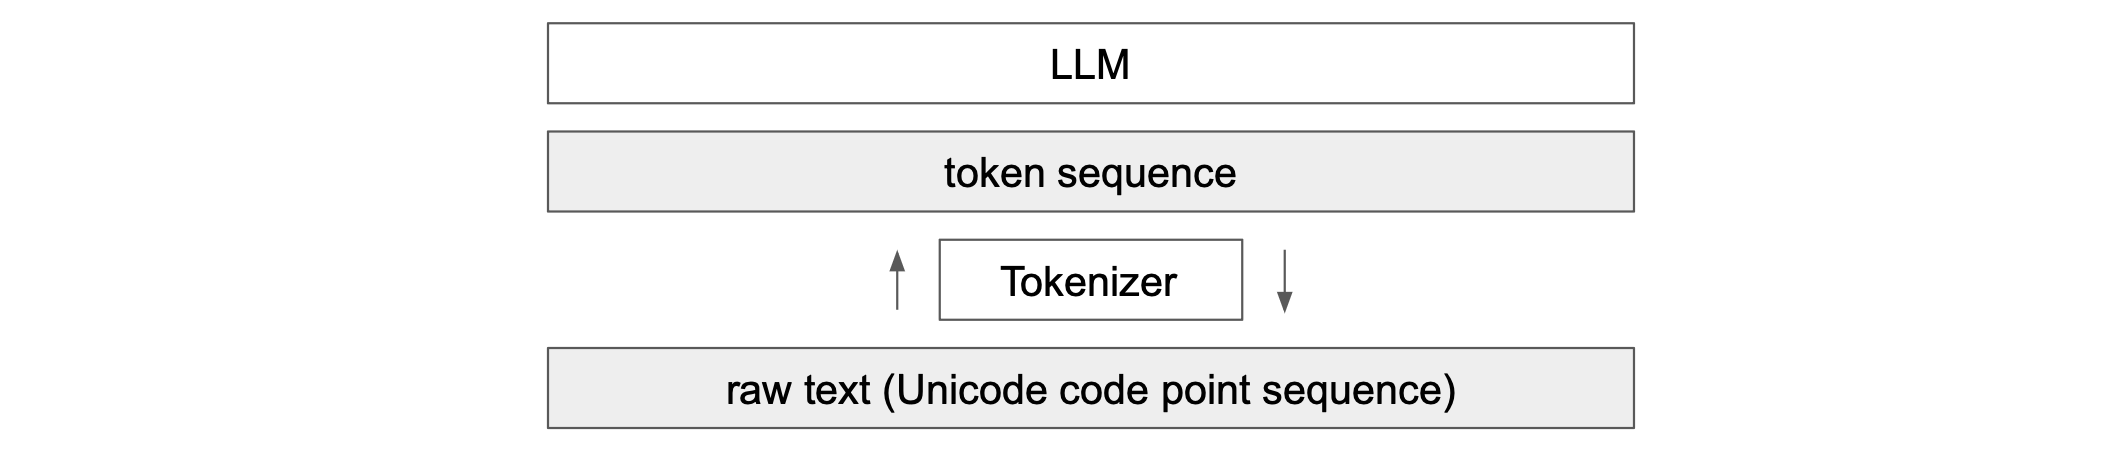

## Decoding: From Tokens Back to Text

Now that we have a trained tokenizer, we need to be able to convert sequences of token IDs back into readable text. This is the **decoding** process, which is the inverse of tokenization.

**The Decoding Problem:** Given a sequence of integers in the range `[0, vocab_size]`, how do we reconstruct the original text?

To solve this, we'll build a vocabulary dictionary that maps each token ID to its corresponding bytes. We start with our base vocabulary of 256 single-byte tokens, then add all the merged pairs we learned during training.

In [11]:
vocab = {idx: bytes([idx]) for idx in range(256)}
for (p0, p1), idx in MERGES.items():
    vocab[idx] = vocab[p0] + vocab[p1]

def decode(ids):
  # given ids (list of integers), return Python string
  tokens = b"".join(vocab[idx] for idx in ids)
  text = tokens.decode("utf-8", errors="replace")
  return text

print(decode([128]))

�


## Encoding: From Text to Tokens

Now let's implement the reverse operation: **encoding**. Given a string, we need to convert it into a sequence of token IDs.

This is more complex than decoding because we must iteratively apply the merge rules we learned during training. We start with the raw UTF-8 bytes, then repeatedly identify and merge the most frequently occurring pairs according to our learned vocabulary.

In [12]:
def encode(text):
  # given a string, return list of integers (the tokens)
  tokens = list(text.encode("utf-8"))
  while len(tokens) >= 2:
    stats = get_stats(tokens)
    pair = min(stats, key=lambda p: MERGES.get(p, float("inf")))
    if pair not in MERGES:
      break # nothing else can be merged
    idx = MERGES[pair]
    tokens = merge(tokens, pair, idx)
  return tokens

In [13]:
print(decode(encode("hello world")))

hello world


In [14]:
text2 = decode(encode(text))
print(text2 == text)

True


In [15]:
valtext = "Many common characters, including numerals, punctuation, and other symbols, are unified within the standard and are not treated as specific to any given writing system. Unicode encodes thousands of emoji, with the continued development thereof conducted by the Consortium as a part of the standard.[4] Moreover, the widespread adoption of Unicode was in large part responsible for the initial popularization of emoji outside of Japan. Unicode is ultimately capable of encoding more than 1.1 million characters."
valtext2 = decode(encode(valtext))
print(valtext2 == valtext)

True


# Section 4: Regex-Based Text Splitting (GPT Series)

So far, our BPE implementation operates directly on raw UTF-8 bytes. However, production tokenizers like those used in GPT-2, GPT-3, and GPT-4 add an important preprocessing step: **regex-based forced splits**.

**Why forced splits?** Without them, BPE might learn merges that span across natural language boundaries in undesirable ways. For example, it might merge spaces with adjacent words, making it difficult to reverse whitespace. Or it might combine punctuation with words in inconsistent patterns.

**🎯 Your Turn:** Before we dive into the code, let's see this in action! Visit [tiktokenizer.vercel.app](https://tiktokenizer.vercel.app/) and paste this example:

```
It's 2024! GPT-4 costs $0.03/1K tokens. We've tested it—works great!!! 
Email: contact@openai.com | Phone: +1-555-1234
Numbers: 42 + 58 = 100
```

**Observe:** Notice how the tokenizer handles:
- **Contractions**: `It's` splits into `It` + `'s` (separate tokens)
- **Punctuation clusters**: `!!!` stays together as one token
- **Numbers**: Each number becomes its own token, separate from surrounding text
- **Special characters**: Email symbols, hyphens, and operators get their own tokens
- **Whitespace**: Spaces are often attached to the *following* word

This preprocessing via regex ensures BPE produces cleaner, more consistent tokens!

The GPT series uses regex patterns to split text into **chunks** before applying BPE. Each chunk is tokenized independently. This ensures cleaner, more predictable tokenization by preventing merges across certain boundaries (like between letters and numbers, or before punctuation).

The regex pattern used in the GPT tokenizer can be found [here](https://github.com/openai/gpt-2/blob/master/src/encoder.py). Let's copy and explore it.

A good resource to understand regex patterns is the [Regex101](https://regex101.com/) website, where you can test and visualize regex behavior interactively.

In [16]:
import regex as re
gpt2pat = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""")

We strongly recommend entering the regex pattern into Regex101 and experimenting with various text inputs to see how it splits the text into chunks. This hands-on approach will help solidify your understanding of how regex-based splitting works in tokenization!

In [17]:
print(re.findall(gpt2pat, "Hello've world123 how's are you!!!?"))

['Hello', "'ve", ' world', '123', ' how', "'s", ' are', ' you', '!!!?']


In [18]:
example = """
for i in range(1, 101):
    if i % 3 == 0 and i % 5 == 0:
        print("FizzBuzz")
    elif i % 3 == 0:
        print("Fizz")
    elif i % 5 == 0:
        print("Buzz")
    else:
        print(i)
"""
print(re.findall(gpt2pat, example))

['\n', 'for', ' i', ' in', ' range', '(', '1', ',', ' 101', '):', '\n   ', ' if', ' i', ' %', ' 3', ' ==', ' 0', ' and', ' i', ' %', ' 5', ' ==', ' 0', ':', '\n       ', ' print', '("', 'FizzBuzz', '")', '\n   ', ' elif', ' i', ' %', ' 3', ' ==', ' 0', ':', '\n       ', ' print', '("', 'Fizz', '")', '\n   ', ' elif', ' i', ' %', ' 5', ' ==', ' 0', ':', '\n       ', ' print', '("', 'Buzz', '")', '\n   ', ' else', ':', '\n       ', ' print', '(', 'i', ')', '\n']


# Section 5: Using TikToken (OpenAI's Production Tokenizer)

Now let's use **TikToken**, OpenAI's official tokenizer library. This is the actual tokenizer used in GPT-2, GPT-3, GPT-4, and other OpenAI models. 

We've built our own BPE implementation from scratch to understand the core algorithm. Now we'll see how the production version handles real-world text with all the optimizations and regex patterns we just learned about.

In [19]:
try:
    import tiktoken
    
except ImportError:
    import sys
    import subprocess
    print("Installing tiktoken...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tiktoken"])

    import tiktoken

Installing tiktoken...


In [20]:
# GPT-2 (does not merge spaces)
enc = tiktoken.get_encoding("gpt2")
print(enc.encode("    hello world!!!"))

# GPT-4 (merges spaces)
enc = tiktoken.get_encoding("cl100k_base")
print(enc.encode("    hello world!!!"))

[220, 220, 220, 23748, 995, 10185]
[262, 24748, 1917, 12340]


In [21]:
enc = tiktoken.get_encoding("cl100k_base") # GPT-4 tokenizer
print(enc.encode(example_text))
print(len(enc.encode(example_text)))
print(enc.decode(enc.encode(example_text)) == example_text)
# match the above for your own tokenizer, and also implement a train() function

[9906, 24252, 11318, 30925, 22071, 149, 233, 5821, 220, 57668, 53901, 15272, 101, 88344, 79468, 31584, 97, 35470, 53677, 7094, 28086, 20812, 83680, 51627, 220, 90115, 88898, 50391, 37769, 251, 96270, 75265, 243, 92245, 62904, 233]
36
True


## Exploring GPT-2's Tokenizer Files

To understand how GPT-2's tokenizer works under the hood, let's download and examine the actual vocabulary files used by the model. You can reference the original [encoder.py](https://github.com/openai/gpt-2/blob/master/src/encoder.py) implementation on GitHub.

We'll download two key files:
- **vocab.bpe**: Contains the BPE merge rules learned during training
- **encoder.json**: Maps tokens to their integer IDs

In [22]:
import os
import urllib.request

os.makedirs('data/openai', exist_ok=True)

# Download vocab.bpe
vocab_url = "https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/vocab.bpe"
vocab_path = "data/openai/vocab.bpe"
if not os.path.exists(vocab_path):
    print("Downloading vocab.bpe...")
    urllib.request.urlretrieve(vocab_url, vocab_path)
    print("✓ vocab.bpe downloaded")

# Download encoder.json
encoder_url = "https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/encoder.json"
encoder_path = "data/openai/encoder.json"
if not os.path.exists(encoder_path):
    print("Downloading encoder.json...")
    urllib.request.urlretrieve(encoder_url, encoder_path)
    print("✓ encoder.json downloaded")

✓ vocab.bpe downloaded
✓ encoder.json downloaded


In [23]:
import json

with open('data/openai/encoder.json', 'r') as f:
    encoder = json.load(f) # <--- ~equivalent to our "vocab"

print("Length of encoder vocab:", len(encoder))

with open('data/openai/vocab.bpe', 'r', encoding="utf-8") as f:
    bpe_data = f.read()

bpe_merges = [tuple(merge_str.split()) for merge_str in bpe_data.split('\n')[1:-1]]
print("Number of BPE merges:", len(bpe_merges))

Length of encoder vocab: 50257
Number of BPE merges: 50000


In [24]:
# The only special token in use for the GPT-2 base model
encoder['<|endoftext|>'] 

50256

## SentencePiece: An Alternative Tokenization Approach

**SentencePiece** is another popular BPE tokenization library, widely used in models like **Llama** and **Mistral**. Unlike TikToken (which only does inference), SentencePiece can both **train** and **run** BPE tokenizers efficiently.

🔗 [SentencePiece on GitHub](https://github.com/google/sentencepiece)

### Key Difference: Code Points vs. Bytes

The fundamental difference between SentencePiece and TikToken lies in **what they tokenize**:

| Library | Approach | Process |
|---------|----------|---------|
| **TikToken** | Byte-level BPE | Text → UTF-8 bytes → BPE on bytes |
| **SentencePiece** | Code point BPE | Text → Unicode code points → BPE on code points → (optional byte fallback) |

**SentencePiece's approach:**
1. Applies BPE directly on Unicode code points
2. Uses `character_coverage` parameter to handle rare code points
3. For very rare characters, either:
   - Maps them to an `<UNK>` (unknown) token, OR
   - Falls back to UTF-8 byte encoding if `byte_fallback=True`

**Which is better?** 
The TikToken approach (byte-level BPE) is arguably cleaner and more consistent—it treats all text uniformly as bytes. SentencePiece's code point approach can be more linguistically motivated but adds complexity with the fallback mechanism.

In [25]:
try:
    import sentencepiece as spm
    
except ImportError:
    import sys
    import subprocess
    print("Installing sentencepiece...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentencepiece"])

    import sentencepiece as spm

In [26]:
os.makedirs('data/sentencepiece', exist_ok=True)

# write a toy.txt file with some random text
with open("data/sentencepiece/toy.txt", "w", encoding="utf-8") as f:
  f.write("SentencePiece is an unsupervised text tokenizer and detokenizer mainly for Neural Network-based text generation systems where the vocabulary size is predetermined prior to the neural model training. SentencePiece implements subword units (e.g., byte-pair-encoding (BPE) [Sennrich et al.]) and unigram language model [Kudo.]) with the extension of direct training from raw sentences. SentencePiece allows us to make a purely end-to-end system that does not depend on language-specific pre/postprocessing.")

### Training a SentencePiece Model

Now let's train our own SentencePiece tokenizer! The code below shows the configuration options used.

**📚 SentencePiece Documentation:**
- [Training Options Guide](https://github.com/google/sentencepiece/blob/master/doc/options.md) - Comprehensive list of all training parameters
- [Protobuf Spec](https://github.com/google/sentencepiece/blob/master/src/sentencepiece_model.proto#L193) - Technical specification of model parameters

The configuration below mirrors the settings used for training **Llama 2** tokenizer.

In [27]:
import os
import sentencepiece as spm

# Training configuration mirroring Llama 2 tokenizer settings
options = dict(
    # Input specification
    input="data/sentencepiece/toy.txt",
    input_format="text",
    
    # Output specification
    model_prefix="data/sentencepiece/tok400",  # Output filename prefix
    
    # Algorithm: BPE with 400 vocabulary size
    model_type="bpe",
    vocab_size=400,
    
    # Normalization: disabled to preserve original text
    normalization_rule_name="identity",  # No normalization
    remove_extra_whitespaces=False,
    
    # Training data limits
    input_sentence_size=200000000,  # Max number of training sentences
    max_sentence_length=4192,        # Max bytes per sentence
    seed_sentencepiece_size=1000000,
    shuffle_input_sentence=True,
    
    # Rare word treatment
    character_coverage=0.99995,  # Coverage of characters in training data
    byte_fallback=True,          # Fall back to UTF-8 bytes for rare characters
    
    # Tokenization rules
    split_digits=True,               # Separate digits into individual tokens
    split_by_unicode_script=True,    # Split by script boundaries (e.g., Latin/Cyrillic)
    split_by_whitespace=True,        # Split on whitespace
    split_by_number=True,            # Split numbers separately
    max_sentencepiece_length=16,    # Maximum length of a token
    add_dummy_prefix=True,           # Add space prefix to first word (handles word boundaries)
    allow_whitespace_only_pieces=True,
    
    # Special tokens
    unk_id=0,   # Unknown token (required)
    bos_id=1,   # Beginning of sentence token
    eos_id=2,   # End of sentence token
    pad_id=-1,  # Padding token (disabled with -1)
    
    # System resources
    num_threads=os.cpu_count(),  # Use all available CPU cores
)

# Train the tokenizer
spm.SentencePieceTrainer.train(**options)
print(f"✓ Trained SentencePiece model: {options['model_prefix']}.model")

✓ Trained SentencePiece model: data/sentencepiece/tok400.model


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: data/sentencepiece/toy.txt
  input_format: text
  model_prefix: data/sentencepiece/tok400
  model_type: BPE
  vocab_size: 400
  self_test_sample_size: 0
  character_coverage: 0.99995
  input_sentence_size: 200000000
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 64
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 1
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 1
  required_chars: 
  byte_fallback: 1
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
 

In [28]:
# Load the trained model
sp = spm.SentencePieceProcessor()
sp.load('data/sentencepiece/tok400.model')

# Display the vocabulary: [token_string, token_id]
vocab = [[sp.id_to_piece(idx), idx] for idx in range(sp.get_piece_size())]
print(f"Vocabulary size: {len(vocab)}")
print(vocab[:20])  # Show first 20 tokens

Vocabulary size: 400
[['<unk>', 0], ['<s>', 1], ['</s>', 2], ['<0x00>', 3], ['<0x01>', 4], ['<0x02>', 5], ['<0x03>', 6], ['<0x04>', 7], ['<0x05>', 8], ['<0x06>', 9], ['<0x07>', 10], ['<0x08>', 11], ['<0x09>', 12], ['<0x0A>', 13], ['<0x0B>', 14], ['<0x0C>', 15], ['<0x0D>', 16], ['<0x0E>', 17], ['<0x0F>', 18], ['<0x10>', 19]]


In [29]:
ids = sp.encode(example_text)
print(ids)

[362, 75, 361, 372, 358, 362, 220, 136, 219, 180, 219, 176, 219, 171, 220, 142, 219, 170, 362, 231, 192, 163, 232, 168, 192, 362, 227, 167, 171, 227, 167, 177, 227, 167, 187, 227, 168, 144, 227, 167, 167, 227, 168, 138, 362, 211, 154, 211, 183, 212, 131, 211, 179, 211, 181, 212, 132, 212, 133, 211, 181, 212, 134, 211, 188, 212, 133, 211, 184, 362, 230, 132, 150, 230, 133, 150, 230, 132, 174, 230, 132, 164, 230, 132, 178, 362, 218, 172, 218, 159, 218, 152, 218, 160, 362, 239, 152, 139, 238, 136, 152, 240, 152, 155, 239, 135, 187, 239, 157, 151, 362, 243, 162, 148, 142]


In [30]:
print([sp.id_to_piece(idx) for idx in ids])

['▁', '<0x48>', 'e', 'l', 'lo', '▁', '<0xD9>', '<0x85>', '<0xD8>', '<0xB1>', '<0xD8>', '<0xAD>', '<0xD8>', '<0xA8>', '<0xD9>', '<0x8B>', '<0xD8>', '<0xA7>', '▁', '<0xE4>', '<0xBD>', '<0xA0>', '<0xE5>', '<0xA5>', '<0xBD>', '▁', '<0xE0>', '<0xA4>', '<0xA8>', '<0xE0>', '<0xA4>', '<0xAE>', '<0xE0>', '<0xA4>', '<0xB8>', '<0xE0>', '<0xA5>', '<0x8D>', '<0xE0>', '<0xA4>', '<0xA4>', '<0xE0>', '<0xA5>', '<0x87>', '▁', '<0xD0>', '<0x97>', '<0xD0>', '<0xB4>', '<0xD1>', '<0x80>', '<0xD0>', '<0xB0>', '<0xD0>', '<0xB2>', '<0xD1>', '<0x81>', '<0xD1>', '<0x82>', '<0xD0>', '<0xB2>', '<0xD1>', '<0x83>', '<0xD0>', '<0xB9>', '<0xD1>', '<0x82>', '<0xD0>', '<0xB5>', '▁', '<0xE3>', '<0x81>', '<0x93>', '<0xE3>', '<0x82>', '<0x93>', '<0xE3>', '<0x81>', '<0xAB>', '<0xE3>', '<0x81>', '<0xA1>', '<0xE3>', '<0x81>', '<0xAF>', '▁', '<0xD7>', '<0xA9>', '<0xD7>', '<0x9C>', '<0xD7>', '<0x95>', '<0xD7>', '<0x9D>', '▁', '<0xEC>', '<0x95>', '<0x88>', '<0xEB>', '<0x85>', '<0x95>', '<0xED>', '<0x95>', '<0x98>', '<0xEC>', '<0

### Llama 2 Tokenizer Configuration

Want to see the actual configuration used for Llama 2's production tokenizer? Meta released their `tokenizer.model` file, and we can inspect its protocol buffer specification.

**How to export:** See this [helpful GitHub issue](https://github.com/google/sentencepiece/issues/121) for instructions on exporting the raw protocol buffer.

**Llama 2's actual configuration:**

```protobuf
normalizer_spec {
  name: "identity"
  precompiled_charsmap: ""
  add_dummy_prefix: true
  remove_extra_whitespaces: false
  normalization_rule_tsv: ""
}

trainer_spec {
  input: "/large_experiments/theorem/datasets/MERGED/all.test1.merged"
  model_prefix: "spm_model_32k_200M_charcov099995_allowWSO__v2"
  model_type: BPE
  vocab_size: 32000                  # Much larger than our toy example!
  self_test_sample_size: 0
  input_format: "text"
  character_coverage: 0.99995
  input_sentence_size: 200000000     # 200M sentences for training
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  num_threads: 80                    # Parallel training with 80 threads
  num_sub_iterations: 2
  max_sentence_length: 4192
  shuffle_input_sentence: true
  max_sentencepiece_length: 16
  split_by_unicode_script: true
  split_by_whitespace: true
  split_by_number: true
  treat_whitespace_as_suffix: false
  split_digits: true
  allow_whitespace_only_pieces: true
  vocabulary_output_piece_score: true
  hard_vocab_limit: true
  use_all_vocab: false
  byte_fallback: true                # UTF-8 byte fallback enabled
  required_chars: ""
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_surface: " ⁇ "
  unk_piece: "<unk>"
  bos_piece: "<s>"
  eos_piece: "</s>"
  pad_piece: "<pad>"
  train_extremely_large_corpus: false
  enable_differential_privacy: false
  differential_privacy_noise_level: 0.0
  differential_privacy_clipping_threshold: 0
}
```

**Key observations:**
- **Vocabulary size: 32,000 tokens** (vs. our toy 400)
- **Trained on 200M sentences** from a large merged dataset
- **80 threads** for parallel training
- Uses **byte_fallback** for rare characters
- Special tokens: `<unk>`, `<s>` (BOS), `</s>` (EOS)

### Choosing Vocabulary Size

**Common questions about vocabulary size:**

**Q: What should my vocabulary size be?**
- **Small models (< 1B params):** 8K - 32K tokens
  - GPT-2: 50,257 tokens
  - Llama 2 (7B): 32,000 tokens
- **Large models (> 10B params):** 32K - 100K+ tokens
  - GPT-4: ~100K tokens (cl100k_base)
  - Gemini: 256K tokens

**Q: How can I increase vocabulary size?**

To increase vocab size, you need to:
1. **Train with more merges** - Run more BPE iterations (higher `vocab_size` in SentencePiece)
2. **Use more training data** - Larger corpus = more diverse patterns to learn
3. **Adjust character_coverage** - Lower values (e.g., 0.995 vs 0.99995) create more byte fallback tokens

**Trade-offs:**
- ✅ **Larger vocab** = Better compression, fewer tokens per text, more efficient
- ❌ **Larger vocab** = Larger embedding matrix, more memory, slower training
- ⚖️ **Sweet spot:** Balance between compression efficiency and model size

**Reference:** See [gpt.py](https://github.com/karpathy/ng-video-lecture/blob/master/gpt.py) for implementation details.

## Final Recommendations & Best Practices

### Key Takeaways

**1. Don't underestimate tokenization!**
- Tokenization is a source of many LLM quirks and limitations
- Security vulnerabilities can arise from tokenization edge cases
- Safety issues in content filtering often trace back to tokenization
- Understanding tokenization helps debug mysterious model behaviors

**2. The future: Tokenization-free LLMs?**
- Current tokenization adds complexity and potential issues
- Research is ongoing into character-level or byte-level models that don't require explicit tokenization
- Until then, we must work with BPE and its variants

### Practical Guidance for Your Projects

**Option 1: Reuse existing tokenizers (Recommended for most cases)**
- ✅ Use GPT-4's tokenizer via `tiktoken` for English-focused applications
- ✅ Well-tested, efficient, and handles edge cases
- ✅ Compatible with many existing models and tools
- Example: `tiktoken.get_encoding("cl100k_base")`

**Option 2: Train your own tokenizer**
- When to consider: Domain-specific vocabulary (code, medical, legal), multilingual models
- ✅ Use **SentencePiece** with BPE algorithm
- ⚠️ **Be careful:** Many configuration options with non-obvious effects
- 🔍 **Test thoroughly:** Verify behavior on edge cases (rare characters, special symbols, mixed scripts)
- 📊 **Monitor:** Character coverage, vocabulary size, compression ratio

**Option 3: Educational implementations**
- Use **minbpe** for learning and experimentation
- Once it achieves production-grade efficiency, consider for real applications
- Great for understanding the internals!

### Resources for Further Learning

- [Andrej Karpathy's minbpe](https://github.com/karpathy/minbpe) - Clean, educational BPE implementation
- [TikToken Documentation](https://github.com/openai/tiktoken) - OpenAI's production tokenizer
- [SentencePiece](https://github.com/google/sentencepiece) - Google's tokenization library
- [A Programmer's Introduction to Unicode](http://reedbeta.com/blog/programmers-intro-to-unicode/) - Nathan Reed's excellent guide